# L3 · Notebook 01 — Bellman 最优算子 $T$

**对应教材**：`miclDRL/chapters/part2-ch03-bellman-optimality.tex`

## 教学目标

$$
[Tv](s) := \max_a \Big[ r(s,a) + \gamma \sum_{s'} P(s'|s,a)\, v(s') \Big]
$$

1. 实现 $T$ 算子
2. **数值验证 γ-收缩**：随机 V₁, V₂，看 $\|TV_1 - TV_2\|_\infty / \|V_1 - V_2\|_\infty \le \gamma$
3. **不动点迭代**：从 $v=0$ 反复施 $T$，会得到 $v^*$
4. 验证 $v^* = Tv^*$

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from shared.grid_world import GridWorld
from shared.plotting import plot_value_heatmap, plot_policy_arrows, setup_chinese_font

setup_chinese_font()
env = GridWorld()
n = env.n_states
gamma = env.cfg.gamma
print(f'|S|={n}, γ={gamma}')

|S|=25, γ=0.9


## 1. 实现 $T$ 算子

In [2]:
def T_optimal(env, V):
    """返回 (TV, greedy_actions_idx). V 形状 (|S|,)"""
    Q = env.compute_q_table(V)  # (|S|, |A|)
    return Q.max(axis=1), Q.argmax(axis=1)

# 试一下：T 在 V=0 上
TV0, _ = T_optimal(env, np.zeros(n))
print('T(0) reshape 5×5:')
print(TV0.reshape(5, 5).round(3))
print('\n说明：T(0)[s] = max_a r(s,a)。target 邻居（s13,s17,s19,s23）有 +1；撞墙状态 -1；其它 0。')

T(0) reshape 5×5:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 1. 0.]
 [0. 0. 1. 0. 0.]]

说明：T(0)[s] = max_a r(s,a)。target 邻居（s13,s17,s19,s23）有 +1；撞墙状态 -1；其它 0。


## 2. 数值验证 γ-收缩

**Banach 不动点定理**的关键条件：算子是 γ-Lipschitz：
$$
\|TV_1 - TV_2\|_\infty \le \gamma \|V_1 - V_2\|_\infty
$$
随机生成 30 对 V，统计实证比值。

In [3]:
rng = np.random.default_rng(0)
ratios = []
for _ in range(30):
    V1 = rng.uniform(-2, 2, n)
    V2 = rng.uniform(-2, 2, n)
    TV1, _ = T_optimal(env, V1)
    TV2, _ = T_optimal(env, V2)
    num = np.max(np.abs(TV1 - TV2))
    den = np.max(np.abs(V1 - V2))
    ratios.append(num / den)

ratios = np.array(ratios)
print(f'30 对随机 (V1, V2) 的实测比值 ||TV1-TV2||/||V1-V2||:')
print(f'  mean = {ratios.mean():.4f}')
print(f'  max  = {ratios.max():.4f}  (应 ≤ γ = {gamma})')
print(f'  min  = {ratios.min():.4f}')
assert ratios.max() <= gamma + 1e-12, 'γ-收缩被打破！'

30 对随机 (V1, V2) 的实测比值 ||TV1-TV2||/||V1-V2||:
  mean = 0.6003
  max  = 0.9000  (应 ≤ γ = 0.9)
  min  = 0.3283


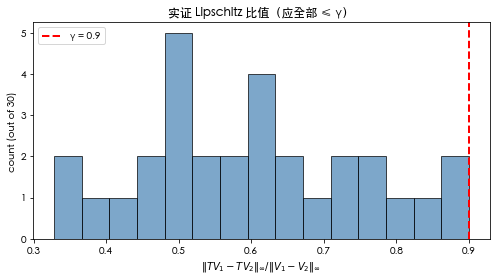

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ratios, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(gamma, color='red', linestyle='--', linewidth=2, label=f'γ = {gamma}')
ax.set_xlabel(r'$\|TV_1 - TV_2\|_\infty / \|V_1 - V_2\|_\infty$')
ax.set_ylabel('count (out of 30)')
ax.set_title('实证 Lipschitz 比值（应全部 ≤ γ）')
ax.legend()
plt.tight_layout()
plt.savefig('figures/contraction_ratios.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. 不动点迭代：从 V=0 → V*

In [5]:
V = np.zeros(n)
history = [V.copy()]
residuals = []
for k in range(200):
    V_new, _ = T_optimal(env, V)
    residuals.append(np.max(np.abs(V_new - V)))
    V = V_new
    history.append(V.copy())
    if residuals[-1] < 1e-12:
        break

V_star = V
_, greedy_idx = T_optimal(env, V_star)
policy_star = {s: env.actions[greedy_idx[env.state_index(s)]] for s in env.all_states()}
print(f'收敛于第 {len(residuals)} 轮，最终残差 {residuals[-1]:.2e}')
print('V* reshape 5×5:')
print(V_star.reshape(5, 5).round(3))

收敛于第 10 轮，最终残差 0.00e+00
V* reshape 5×5:
[[0.531 0.478 0.43  0.478 0.531]
 [0.59  0.531 0.478 0.531 0.59 ]
 [0.656 0.59  1.    0.59  0.656]
 [0.729 1.    0.    1.    0.729]
 [0.81  0.9   1.    0.9   0.81 ]]


## 4. 验证 $V^* = TV^*$（不动点条件）

In [6]:
TV_star, _ = T_optimal(env, V_star)
print(f'||V* - T(V*)||_∞ = {np.max(np.abs(V_star - TV_star)):.2e}  (理论应为 0)')

||V* - T(V*)||_∞ = 0.00e+00  (理论应为 0)


## 5. 收敛过程可视化：3 个快照（k=0, k=5, k=收敛）

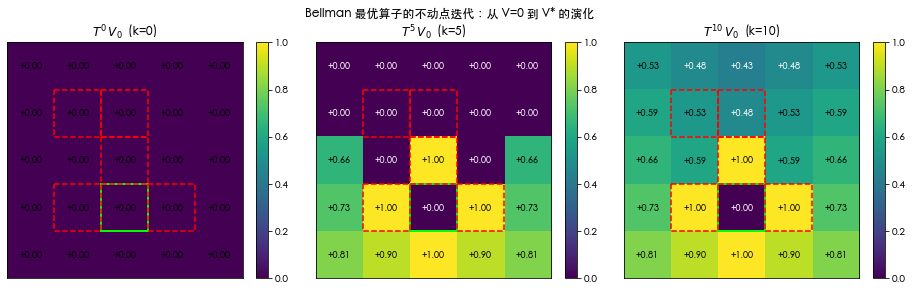

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
snaps = [0, 5, len(history) - 1]
for ax, k in zip(axes, snaps):
    plot_value_heatmap(env, history[k], ax=ax,
                       title=f'$T^{{{k}}}\\,V_0$  (k={k})',
                       vmin=V_star.min(), vmax=V_star.max())
fig.suptitle('Bellman 最优算子的不动点迭代：从 V=0 到 V* 的演化')
plt.tight_layout()
plt.savefig('figures/T_iteration_snapshots.png', dpi=120, bbox_inches='tight')
plt.show()

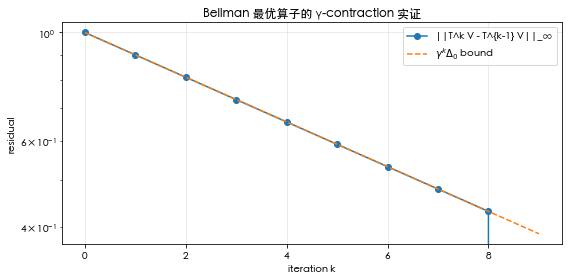

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(residuals, 'o-', label='||T^k V - T^{k-1} V||_∞')
bound = [residuals[0] * gamma**k for k in range(len(residuals))]
ax.semilogy(bound, '--', label=r'$\gamma^k \Delta_0$ bound')
ax.set_xlabel('iteration k'); ax.set_ylabel('residual')
ax.set_title('Bellman 最优算子的 γ-contraction 实证')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('figures/T_residual.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. 课堂诊断小结

| 论断 | 数值 |
|---|---|
| $T$ 是 γ-Lipschitz | 30 次随机采样最大比值 ≤ γ |
| 不动点存在唯一（Banach）| 任意初值都收敛 |
| $V^* = TV^*$ | 残差 < 1e-12 |
| 贪婪策略 = argmax Q | 与 L4 VI 输出一致 |

## 思考题

1. $T$ 含 max，$T_\pi$（L2 的策略评估算子）不含 max。两者收缩系数都是 γ，证明思路有什么不同？
2. 如果 γ=1，$T$ 还是收缩吗？这时怎么办？
3. 把 $T$ 算子写成矩阵形式可能吗？（提示：max 是非线性，但每次迭代后 max 给出一个具体策略，于是局部线性）